In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

resume_df = pd.read_csv("resume.csv")
resume_df.head()

,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ----- Data Loading and Preprocessing -----

# Load the dataset and clean column names
df = pd.read_csv("resume.csv")
df.columns = df.columns.str.strip()

# Ensure key columns exist:
#   - received_callback (indicator: 0 or 1)
#   - gender (if numeric, map 1: Male, 0: Female)
#   - race (string or numeric labels)
#   - resume_quality (e.g. 'low' or 'high')
#   - years_experience (numeric)
required_cols = ['received_callback', 'gender', 'race', 'resume_quality', 'years_experience']
df = df.dropna(subset=required_cols)

# Convert 'received_callback' to numeric if necessary
df['received_callback'] = pd.to_numeric(df['received_callback'], errors='coerce')

# Map gender values if they are numeric
gender_mapping = {1: 'Male', 0: 'Female'}
if df['gender'].dtype in [np.int64, np.float64]:
    df['gender'] = df['gender'].map(gender_mapping)

# Map resume_quality to a binary numeric value for modeling: low -> 0, high -> 1
quality_mapping = {'low': 0, 'high': 1}
df['resume_quality_num'] = df['resume_quality'].map(quality_mapping)

# ----- Descriptive Statistics and Group Comparisons -----
# Compute overall callback rate
overall_callback_rate = df['received_callback'].mean()
print("Overall Callback Rate:", overall_callback_rate)

# Calculate callback rate by gender
gender_group = df.groupby('gender')['received_callback'].mean()
print("\nCallback Rate by Gender:")
print(gender_group)

# Calculate callback rate by race
race_group = df.groupby('race')['received_callback'].mean()
print("\nCallback Rate by Race:")
print(race_group)

# Contingency table for gender and callback
gender_callback_table = pd.crosstab(df['gender'], df['received_callback'])
print("\nContingency Table (Gender vs. Callback):")
print(gender_callback_table)

# Chi-square test for independence between gender and callback rate
chi2_gender, p_gender, dof_gender, ex_gender = stats.chi2_contingency(gender_callback_table)
print("\nChi-square test (Gender vs. Callback):")
print("Chi2 Statistic:", chi2_gender, "p-value:", p_gender)

# Contingency table for race and callback
race_callback_table = pd.crosstab(df['race'], df['received_callback'])
print("\nContingency Table (Race vs. Callback):")
print(race_callback_table)

# Chi-square test for independence between race and callback rate
chi2_race, p_race, dof_race, ex_race = stats.chi2_contingency(race_callback_table)
print("\nChi-square test (Race vs. Callback):")
print("Chi2 Statistic:", chi2_race, "p-value:", p_race)

# ----- Logistic Regression Modeling -----

# For the logistic regression, predict 'received_callback' using demographic and resume attributes
# Use predictors: gender, race, years_experience, and resume_quality_num

# First, convert categorical predictors into dummy/indicator variables
predictors = ['gender', 'race', 'years_experience', 'resume_quality_num']
X = pd.get_dummies(df[predictors], drop_first=True)
y = df['received_callback']

# Standardize numeric features (here, years_experience and resume_quality_num are numeric)
scaler = StandardScaler()
numeric_cols = ['years_experience', 'resume_quality_num']
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split the data for modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("\nLogistic Regression Results (Predicting Callback):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Examine logistic regression coefficients to see the influence of predictors
coef_df = pd.DataFrame({
    'Predictor': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', ascending=False)
print("\nLogistic Regression Coefficients:")  # Make sure the string is properly closed
print(coef_df)



Overall Callback Rate: 0.08049281314168377

Callback Rate by Gender:
gender
f    0.082488
m    0.073843
Name: received_callback, dtype: float64

Callback Rate by Race:
race
black    0.064476
white    0.096509
Name: received_callback, dtype: float64

Contingency Table (Gender vs. Callback):
received_callback     0    1
gender                      
f                  3437  309
m                  1041   83

Chi-square test (Gender vs. Callback):
Chi2 Statistic: 0.7600406328628064 p-value: 0.3833158069979834

Contingency Table (Race vs. Callback):
received_callback     0    1
race                        
black              2278  157
white              2200  235

Chi-square test (Race vs. Callback):
Chi2 Statistic: 16.44902858418937 p-value: 4.997578389963253e-05

Logistic Regression Results (Predicting Callback):
Accuracy: 0.9267624914442163
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      1354
           1     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

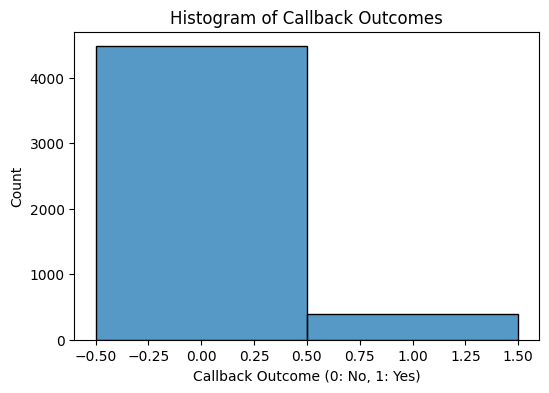

In [23]:
# Histogram of Callback Outcomes
plt.figure(figsize=(6, 4))
sns.histplot(df['received_callback'], bins=2, kde=False, discrete=True)
plt.title("Histogram of Callback Outcomes")
plt.xlabel("Callback Outcome (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

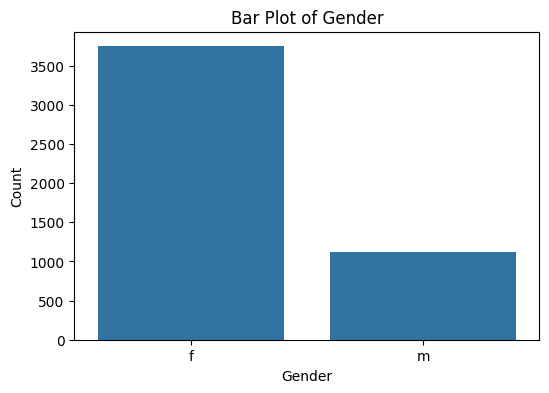

In [24]:
# Gender Bar Plot
plt.figure(figsize=(6, 4))
gender_counts = df['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title("Bar Plot of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

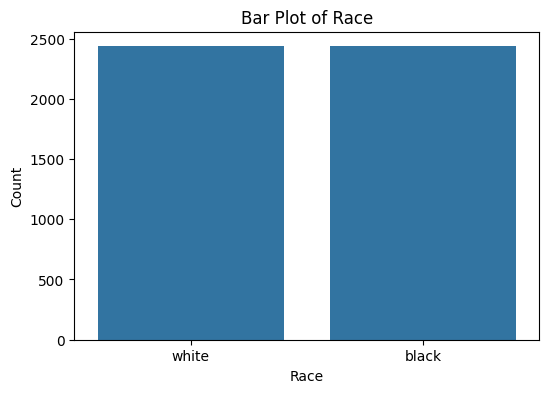

In [25]:
# Race Bar Plot
plt.figure(figsize=(6, 4))
race_counts = df['race'].value_counts()
sns.barplot(x=race_counts.index, y=race_counts.values)
plt.title("Bar Plot of Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()

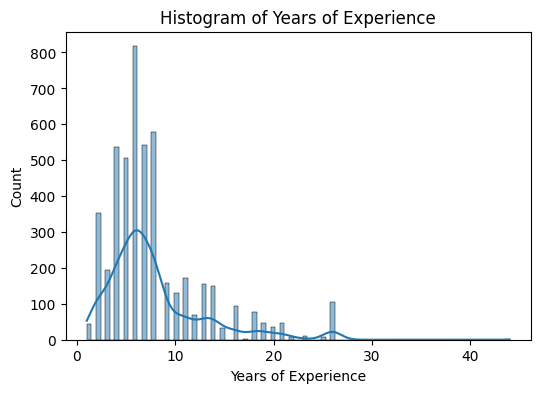

In [26]:
# Histogram of Years of Experience
plt.figure(figsize=(6, 4))
sns.histplot(df['years_experience'], kde=True)
plt.title("Histogram of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()

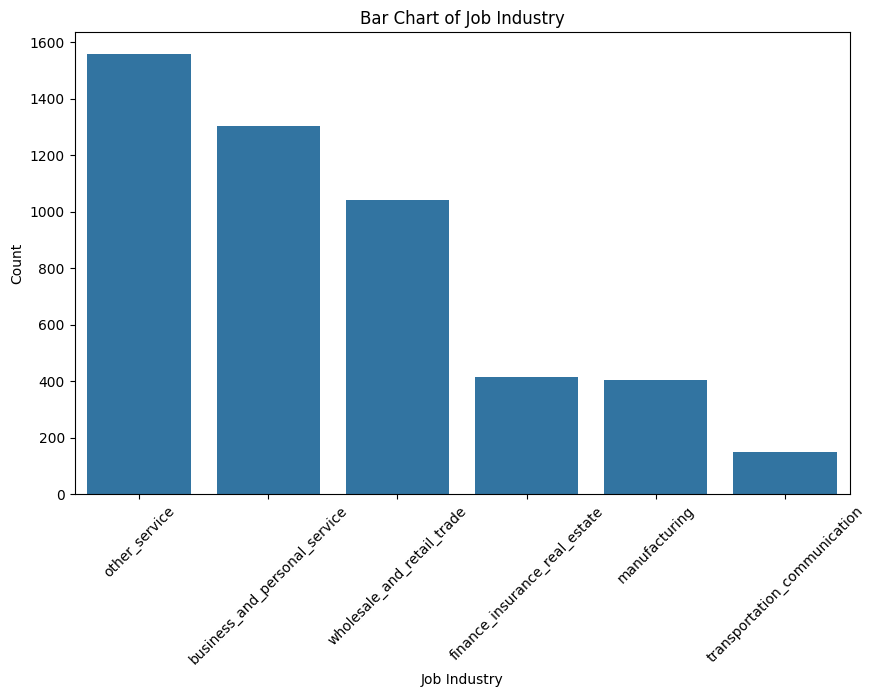

In [27]:
# Job Industry Bar Chart
plt.figure(figsize=(10, 6))
industry_counts = df['job_industry'].value_counts()
sns.barplot(x=industry_counts.index, y=industry_counts.values)
plt.title("Bar Chart of Job Industry")
plt.xlabel("Job Industry")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

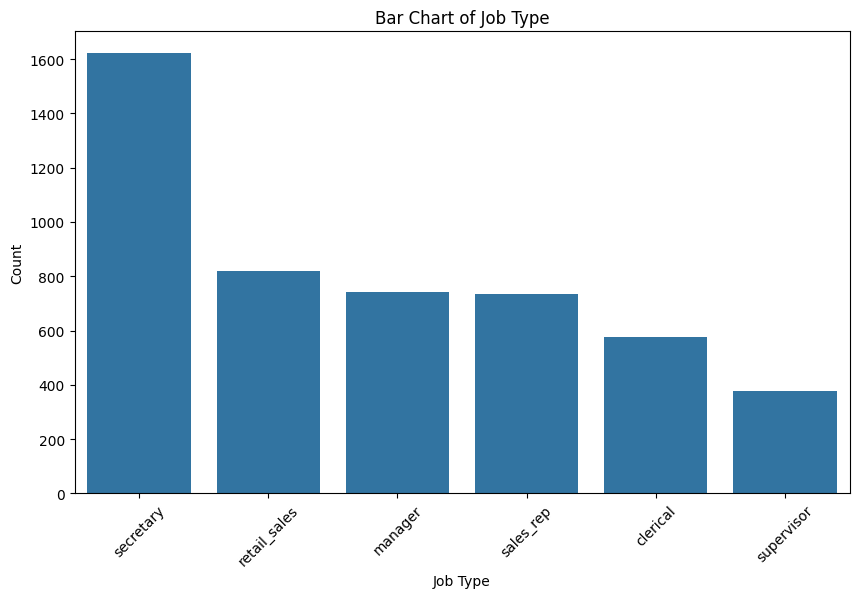

In [28]:
# Job Type Bar Chart
plt.figure(figsize=(10, 6))
job_type_counts = df['job_type'].value_counts()
sns.barplot(x=job_type_counts.index, y=job_type_counts.values)
plt.title("Bar Chart of Job Type")
plt.xlabel("Job Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

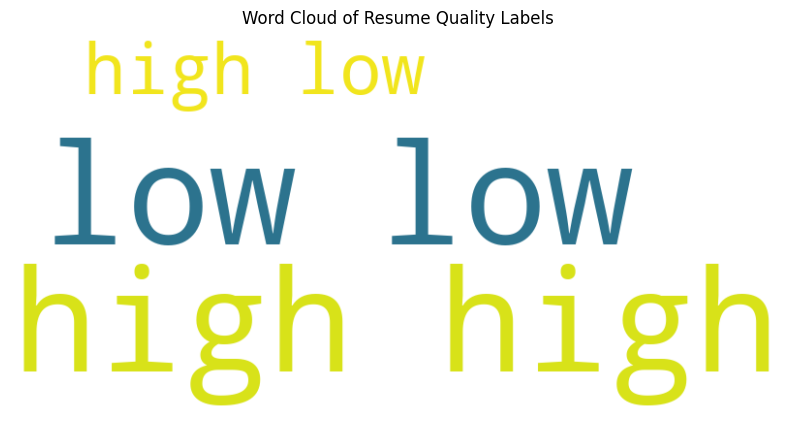

In [29]:
from wordcloud import WordCloud
# Word Cloud of Resume Quality Labels
# Generate a word cloud from resume_quality labels.
# Create a combined string with each label repeated by its count.
quality_counts = df['resume_quality'].value_counts()
quality_string = " ".join([((label + " ") * count) for label, count in quality_counts.items()])

wordcloud = WordCloud(background_color="white", width=800, height=400).generate(quality_string)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Resume Quality Labels")
plt.show()

The word cloud shows that our dataset contains both "high" and "low" resume quality labels. The size of each word corresponds to how frequently that label appears, and here “high” and “low” seem roughly similar, indicating a fairly balanced mix of resume qualities.